Initializing

In [1018]:
# setting start time for execution time tracking
import time
start_time = time.time()

# suppress warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Importing Necessary Libraries

In [1019]:
import timesfm
import os
import re
import math
import pmdarima as pm
from time import strptime
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import inspect
from dateutil.relativedelta import relativedelta
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Loading Consumption Dataset

In [1020]:
drug_name = "LPV 100/25 - Pediatric"
sanitized_drug_name = re.sub(r'[\\/*?:"<>|]', "_", drug_name)
print(f"Drug name: {drug_name} | Sanitized drug name: {sanitized_drug_name}")

Drug name: LPV 100/25 - Pediatric | Sanitized drug name: LPV 100_25 - Pediatric


In [1021]:
# mapping for generational drug names
drug_all_india_map = {
    'AL - Adult' : 'abc_3tc_adult_synthetic.csv',
    'ZL - Adult' : 'azt_3tc_adult_synthetic.csv',
    'ATV - Adult' : 'atv_adult_synthetic.csv',
    'DRV - Adult' : 'drv_adult_synthetic.csv',
    'RTV Booster - Adult' : 'rtv_booster_synthetic.csv',
    'AL - Pediatric' : 'abc_3tc_pediatric_synthetic.csv',
    'ZL - Pediatric' : 'azt_3tc_pediatric_synthetic.csv',
    'LPV 100/25 - Pediatric' : 'lpv_pediatric_synthetic.csv',
}

def get_file_name(name):
    return drug_all_india_map.get(name, 'File not found')

user_input = drug_name
file_name = get_file_name(user_input)
print(f"The file name for {user_input} is: {file_name}")

The file name for LPV 100/25 - Pediatric is: lpv_pediatric_synthetic.csv


In [1022]:
file_path = '~/epidemics-art-forecasting/synthetic-data-generation/final_datasets'
final_file_path = f"{file_path}/{file_name}"
all_india_version = pd.read_csv(final_file_path)
all_india_version.set_index(all_india_version.columns[0], inplace=True)
print(all_india_version)

            consumption
date                   
2015-08-01       336219
2015-09-01       329004
2015-10-01       345321
2015-11-01       363414
2015-12-01       336885
...                 ...
2023-11-01       304695
2023-12-01       285270
2024-01-01       299256
2024-02-01       299256
2024-03-01       290931

[104 rows x 1 columns]


In [1023]:
def parse_date(date_str):
    try:
        # Try parsing as yyyy-mm-dd
        return pd.to_datetime(date_str, format='%Y-%m-%d')
    except ValueError:
        # If it fails, try parsing as yyyy-dd-mm
        return pd.to_datetime(date_str, format='%Y-%d-%m')
all_india_version.index = all_india_version.index.map(parse_date).date
all_india_version

,consumption
2015-08-01,336219
2015-09-01,329004
2015-10-01,345321
2015-11-01,363414
2015-12-01,336885
...,...
2023-11-01,304695
2023-12-01,285270
2024-01-01,299256
2024-02-01,299256


Prediction Window

In [1024]:
prediction_years = 1.5 # for 0.25 is 3 months, 0.5 is for 6 months and so on
months_per_year = 12
prediction_window = int(prediction_years * months_per_year)
print(f"Prediction Window: {prediction_window} months")

Prediction Window: 18 months


Splitting Training and Testing Data

In [1025]:
# separating the data into training and testing
testing_data = all_india_version.tail(prediction_window)
print("Testing Data:")
print(testing_data)

Testing Data:
            consumption
2022-10-01       331557
2022-11-01       322566
2022-12-01       309246
2023-01-01       326229
2023-02-01       319902
2023-03-01       334110
2023-04-01       306249
2023-05-01       310911
2023-06-01       308580
2023-07-01       290487
2023-08-01       316905
2023-09-01       315018
2023-10-01       309690
2023-11-01       304695
2023-12-01       285270
2024-01-01       299256
2024-02-01       299256
2024-03-01       290931


In [1026]:
training_data = all_india_version.iloc[:-prediction_window]
print("Training Data:")
print(training_data)

Training Data:
            consumption
2015-08-01       336219
2015-09-01       329004
2015-10-01       345321
2015-11-01       363414
2015-12-01       336885
...                 ...
2022-05-01       488511
2022-06-01       338994
2022-07-01       154068
2022-08-01       303585
2022-09-01       308691

[86 rows x 1 columns]


Exploratory Visual Analysis

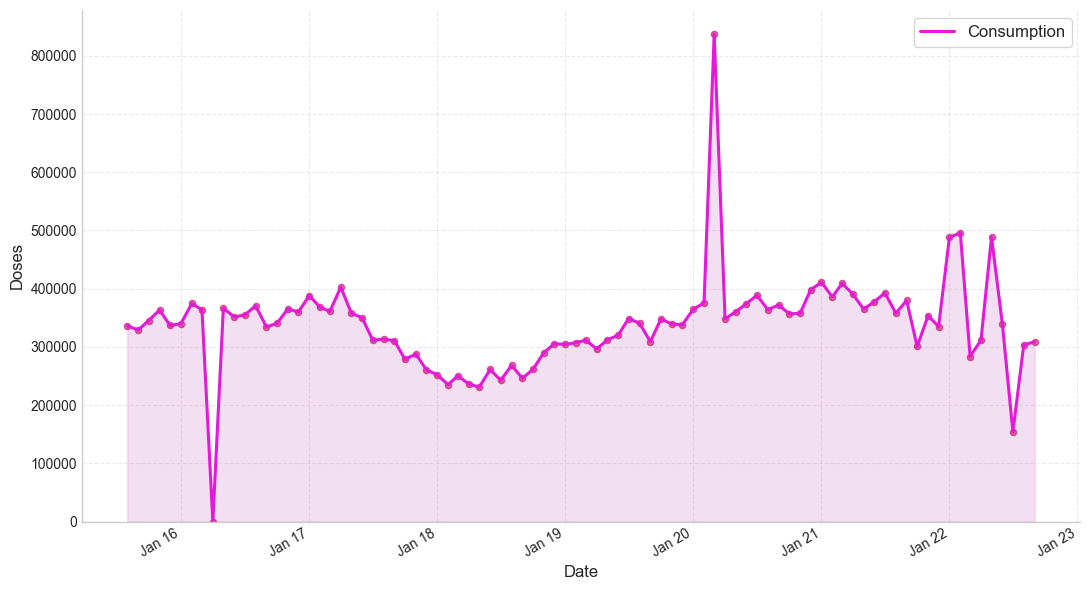

In [1027]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

ax.fill_between(training_data.index, training_data['consumption'], 0,
                color="#C760BF", alpha=0.2)

ax.plot(training_data.index, training_data['consumption'],
        label="Consumption",
        linewidth=2.2,
        color="#E519D8")

ax.scatter(training_data.index, training_data['consumption'],
           color="#CB0869", s=20, alpha=0.6)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=30, ha="right")

ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Doses", fontsize=12)
ax.legend(frameon=True, fontsize=12, loc="upper right", fancybox=True)
ax.set_ylim(bottom=0)

sns.despine()
plt.tight_layout()
os.makedirs("synth_comparison_graphs", exist_ok=True)
plt.savefig(f"synth_comparison_graphs/{sanitized_drug_name}_consumption_area.png", dpi=300)
plt.show()

Generating Log Transformed Values

In [1028]:
log_transformed_values = np.log(training_data['consumption'].values + 1)
log_transformed_values

array([12.72552099, 12.70382823, 12.75223259, 12.80330071, 12.72749987,
       12.73668325, 12.83368347, 12.80452171,  0.        , 12.81151366,
       12.7703888 , 12.77918833, 12.82325898, 12.71956072, 12.7383143 ,
       12.80847969, 12.79347868, 12.86947943, 12.81544412, 12.79717326,
       12.90624509, 12.78822122, 12.76564272, 12.64940499, 12.65544299,
       12.64619358, 12.53757182, 12.56971873, 12.47213008, 12.43706928,
       12.36823401, 12.43088281, 12.3729421 , 12.34965771, 12.47340532,
       12.39890543, 12.49981631, 12.41344447, 12.47383003, 12.57778791,
       12.62961667, 12.62597635, 12.63577498, 12.64940499, 12.59974179,
       12.65118466, 12.67612002, 12.76214789, 12.73896598, 12.6408182 ,
       12.75991753, 12.73537649, 12.73078934, 12.80604586, 12.83664205,
       13.63750886, 12.76055528, 12.79440361, 12.83309071, 12.87062229,
       12.80482673, 12.82654698, 12.78542663, 12.78666964, 12.89432537,
       12.92643122, 12.86345792, 12.92210104, 12.8748964 , 12.80

Traditional Forecasting Method

In [1029]:
# Holt-Winters Exponential Smoothing Model
hw_model = ExponentialSmoothing(
    training_data['consumption'],
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
).fit(
    optimized=True,
    method='L-BFGS-B',
    use_brute=True,
    remove_bias=True,
)

if not hw_model.mle_retvals.get('success', True):
    raise RuntimeError('Holt-Winters optimization failed to converge.')

/Users/muskaanchugh/epidemics-art-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Advanced Forecasting Models

In [1030]:
# TimesFM Model
tfm = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend="mpu",
          per_core_batch_size=32,
          horizon_len=prediction_window,
      ),
      checkpoint=timesfm.TimesFmCheckpoint(
          huggingface_repo_id="google/timesfm-1.0-200m-pytorch"),
  )

def timesfm_model(training):
    timesfm_prediction = tfm.forecast([training['consumption'].values], freq=[1])
    timesfm_predictions = timesfm_prediction[0][0]
    return timesfm_predictions

def timesfm_ln_model(training, log_transform):
    timesfm_ln_prediction = tfm.forecast([log_transform], freq=[1])
    timesfmlog_predictions = np.expm1(timesfm_ln_prediction[0][0])
    return timesfmlog_predictions

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 66576.25it/s]


In [1031]:
# ARIMA Model
def arima_model(training, log_transform):
    arima_fit = pm.auto_arima(log_transform, start_p=1, start_q=1,
                             max_p=5, max_q=5,
                             seasonal=False,
                             d=1, trace=True,
                             information_criterion='aicc',
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)
    arima_predictions_ln = arima_fit.predict(prediction_window)
    arima_predictions = np.exp(arima_predictions_ln)
    return arima_predictions

In [1032]:
# ARIMA + ErrorTimesFM Model
def arima_errortfm_model(training, percentile, log_transform):
    arima_fit = pm.auto_arima(log_transform, start_p=1, start_q=1,
                             max_p=5, max_q=5,
                             seasonal=False,
                             d=1, trace=True,
                             information_criterion='aicc',
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)
    arima_predictions_ln = arima_fit.predict(prediction_window)
    error = int(percentile/10)

    training_actuals = log_transform[-prediction_window:]
    in_sample_predictions = arima_fit.predict_in_sample()[-prediction_window:]
    tfm_error_input = training_actuals - in_sample_predictions

    tfm_error_output = tfm.forecast([tfm_error_input], freq=[1])
    quantile_index = int(percentile / 10)

    return np.expm1(
        arima_predictions_ln
        + tfm_error_output[1][0][:, quantile_index]
    )

Model Executions

In [1033]:
# Traditional Model: Holt-Winters
holt = hw_model.forecast(prediction_window).to_numpy().round(0)
print(holt)

[309411. 320537. 316519. 328921. 340506. 344220. 255566. 338900. 342844.
 335937. 345932. 319687. 318703. 329830. 325812. 338213. 349799. 353512.]


In [1034]:
# TimesFM
timesfm = timesfm_model(training_data)
print(timesfm)

[293189.88 298075.9  299618.03 304771.28 313864.9  318829.5  319018.97
 323685.1  332684.72 337858.66 332613.34 339412.   347947.4  354868.75
 360879.88 365041.62 371746.97 376955.7 ]


In [1035]:
# TimesFM Log
timesfm_log = timesfm_ln_model(training_data, log_transformed_values)
print(timesfm_log)

[363098.12 359573.25 331286.88 350636.94 354014.78 358610.94 343194.84
 338295.2  308421.22 326224.12 329076.7  326297.88 340227.38 358151.94
 358845.28 326783.38 335325.94 369910.2 ]


In [1036]:
# ARIMA
arima = arima_model(training_data, log_transformed_values)
print(arima)

Performing stepwise search to minimize aicc
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AICC=361.110, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AICC=339.222, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AICC=359.013, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AICC=331.259, Time=0.00 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AICC=328.152, Time=0.01 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AICC=327.167, Time=0.01 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AICC=327.268, Time=0.01 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.04 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.06 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AICC=324.856, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AICC=325.897, Time=0.00 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AICC=324.898, 

In [1037]:
# ARIMA + ErrorTimesFM (30 percentile)
arimatfm_30 = arima_errortfm_model(training_data, 30, log_transformed_values)
print(arimatfm_30)

Performing stepwise search to minimize aicc
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AICC=361.110, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AICC=339.222, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AICC=359.013, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AICC=331.259, Time=0.00 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AICC=328.152, Time=0.01 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AICC=327.167, Time=0.01 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AICC=327.268, Time=0.01 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.05 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.06 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AICC=324.856, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AICC=325.897, Time=0.00 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AICC=324.898, 

In [1038]:
# ARIMA + ErrorTimesFM (70 percentile)
arimatfm_70 = arima_errortfm_model(training_data, 70, log_transformed_values)
print(arimatfm_70)

Performing stepwise search to minimize aicc
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AICC=361.110, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AICC=339.222, Time=0.00 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AICC=359.013, Time=0.00 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AICC=331.259, Time=0.00 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AICC=328.152, Time=0.01 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AICC=327.167, Time=0.01 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AICC=327.268, Time=0.01 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.04 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AICC=inf, Time=0.06 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AICC=324.856, Time=0.01 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AICC=325.897, Time=0.00 sec
 ARIMA(5,1,0)(0,0,0)[0]             : AICC=324.898, 

Tabulating Results

In [1039]:
results_df = pd.DataFrame(index=testing_data.index)

results_df['Actual'] = testing_data['consumption'].values
results_df['Traditional'] = holt
results_df['ARIMA'] = arima
results_df['TimesFM'] = timesfm
results_df['TimesFM Log'] = timesfm_log
results_df['ARIMA+TimesFM 30'] = arimatfm_30
results_df['ARIMA+TimesFM 70'] = arimatfm_70

results_df = results_df.round(0)
results_df

,Actual,Traditional,ARIMA,TimesFM,TimesFM Log,ARIMA+TimesFM 30,ARIMA+TimesFM 70
2022-10-01,331557,309411.0,322971.0,293190.0,363098.0,275314.0,365504.0
2022-11-01,322566,320537.0,322971.0,298076.0,359573.0,280033.0,377582.0
2022-12-01,309246,316519.0,322971.0,299618.0,331287.0,292125.0,401475.0
2023-01-01,326229,328921.0,322971.0,304771.0,350637.0,293905.0,406812.0
2023-02-01,319902,340506.0,322971.0,313865.0,354015.0,298039.0,414447.0
2023-03-01,334110,344220.0,322971.0,318830.0,358611.0,285805.0,397211.0
2023-04-01,306249,255566.0,322971.0,319019.0,343195.0,293985.0,403158.0
2023-05-01,310911,338900.0,322971.0,323685.0,338295.0,296579.0,407896.0
2023-06-01,308580,342844.0,322971.0,332685.0,308421.0,289943.0,400279.0
2023-07-01,290487,335937.0,322971.0,337859.0,326224.0,280354.0,387732.0


Visualizing Graph

In [1040]:
# combining all actual data (training + testing)
full_actual = pd.concat([training_data['consumption'], testing_data['consumption']])

# creating a new dataframe with full range data
visualizer_df = pd.DataFrame(index=full_actual.index)
visualizer_df['Actual'] = full_actual

# adding forecast columns only for the forecast window (testing_data.index)
for col in ['Traditional', 'ARIMA', 'TimesFM', 'TimesFM Log', 'ARIMA+TimesFM 30', 'ARIMA+TimesFM 70']:
    visualizer_df[col] = results_df[col]

visualizer_df = visualizer_df.sort_index()
visualizer_df

,Actual,Traditional,ARIMA,TimesFM,TimesFM Log,ARIMA+TimesFM 30,ARIMA+TimesFM 70
2015-08-01,336219,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,329004,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01,345321,NaN,NaN,NaN,NaN,NaN,NaN
2015-11-01,363414,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-01,336885,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2023-11-01,304695,329830.0,322971.0,354869.0,358152.0,286956.0,402302.0
2023-12-01,285270,325812.0,322971.0,360880.0,358845.0,299023.0,418058.0
2024-01-01,299256,338213.0,322971.0,365042.0,326783.0,307463.0,430696.0
2024-02-01,299256,349799.0,322971.0,371747.0,335326.0,301273.0,423532.0


In [1041]:
# adding the last value from the training data to the results dataframe
last_train_idx = training_data.index[-1]
last_value = training_data['consumption'].values[-1]
print(f"Last training index: {last_train_idx} | Last value: {last_value}")

Last training index: 2022-09-01 | Last value: 308691


In [1042]:
# filling the last training index row for all forecast columns with last_value
for col in ['Traditional', 'ARIMA', 'TimesFM', 'TimesFM Log', 'ARIMA+TimesFM 30', 'ARIMA+TimesFM 70']:
    visualizer_df.at[last_train_idx, col] = last_value

visualizer_df

,Actual,Traditional,ARIMA,TimesFM,TimesFM Log,ARIMA+TimesFM 30,ARIMA+TimesFM 70
2015-08-01,336219,NaN,NaN,NaN,NaN,NaN,NaN
2015-09-01,329004,NaN,NaN,NaN,NaN,NaN,NaN
2015-10-01,345321,NaN,NaN,NaN,NaN,NaN,NaN
2015-11-01,363414,NaN,NaN,NaN,NaN,NaN,NaN
2015-12-01,336885,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2023-11-01,304695,329830.0,322971.0,354869.0,358152.0,286956.0,402302.0
2023-12-01,285270,325812.0,322971.0,360880.0,358845.0,299023.0,418058.0
2024-01-01,299256,338213.0,322971.0,365042.0,326783.0,307463.0,430696.0
2024-02-01,299256,349799.0,322971.0,371747.0,335326.0,301273.0,423532.0


Graph saved in synth_graphs/LPV 100_25 - Pediatric Forecast.png


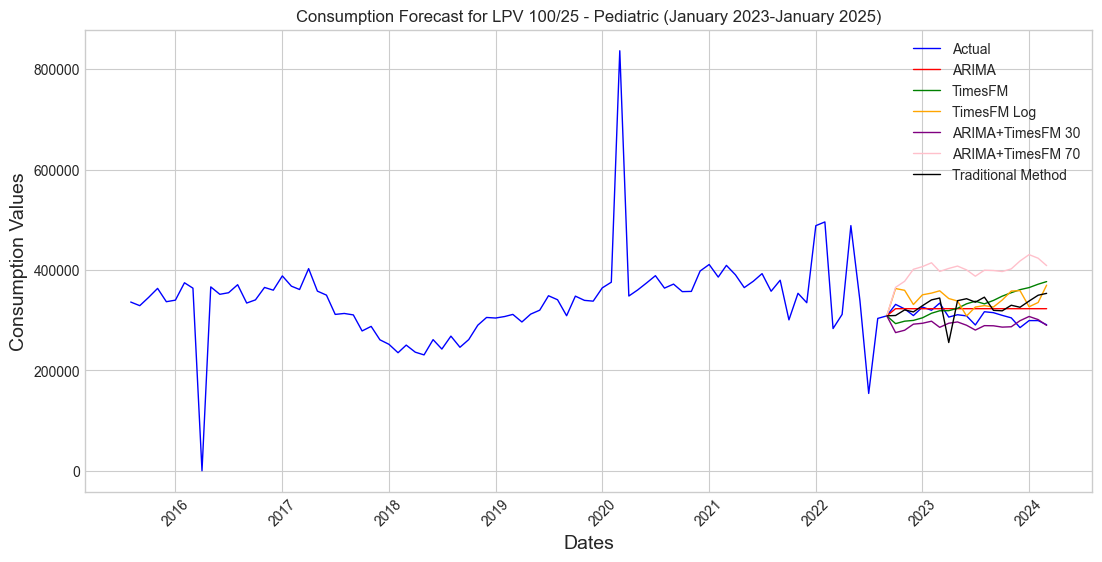

In [1043]:
# plotting the results
fig1, ax1 = plt.subplots(figsize=(13, 6))
visualizer_df['Actual'].plot(ax=ax1, label='Actual', color='blue', linewidth=1)
visualizer_df['ARIMA'].plot(ax=ax1, label='ARIMA', color='red', linewidth=1)
visualizer_df['TimesFM'].plot(ax=ax1, label='TimesFM', color='green', linewidth=1)
visualizer_df['TimesFM Log'].plot(ax=ax1, label='TimesFM Log', color='orange', linewidth=1)
visualizer_df['ARIMA+TimesFM 30'].plot(ax=ax1, label='ARIMA+TimesFM 30', color='purple', linewidth=1)
visualizer_df['ARIMA+TimesFM 70'].plot(ax=ax1, label='ARIMA+TimesFM 70', color='pink', linewidth=1)
visualizer_df['Traditional'].plot(ax=ax1, label='Traditional Method', color='black', linewidth=1)

# plotting a vertical line at September 2022 mentioning the month and year
# ax1.axvline(datetime.datetime(2023, 1, 1), color='black', linestyle='--', linewidth=1)

# adding a rotated text label at the top of the line
'''ymin, ymax = ax1.get_ylim()
y_pos = ymin + 0.5 * (ymax - ymin)
ax1.annotate(
    'January 2023',
    xy=(datetime.datetime(2023, 1, 1), y_pos),
    xytext=(5, -20),               # 5 points right, 5 points up
    textcoords='offset points',
    rotation=90,
    va='bottom',
    ha='left',
    color='black',
    fontsize=10
)'''

# setting the title and labels
graph1_title = f'Consumption Forecast for {drug_name} (January 2023-January 2025)'
ax1.set_title(graph1_title, fontsize=12)
ax1.set_xlabel('Dates', fontsize=14)
ax1.set_ylabel('Consumption Values', fontsize=14)
plt.xticks(rotation=45)
ax1.legend()
ax1.grid(True)
ax1.get_yaxis().get_major_formatter().set_scientific(False)

# saving the graph
graph_output_dir = "synth_graphs"
os.makedirs(graph_output_dir, exist_ok=True)
graph_file_path = os.path.join(graph_output_dir, f"{sanitized_drug_name} Forecast.png")
plt.savefig(graph_file_path)
print(f"Graph saved in {graph_file_path}")

# showing the graph
plt.show()

Statistical Analysis

In [1044]:
# function to calculate Percentage Change (PC) for the Overall Actual vs Overall Predicted
# def calculate_total_percentage_change(actual_total, predicted_total):
#    return ((predicted_total - actual_total) / actual_total) * 100

In [1045]:
def calculate_signed_percentage_deviation(actual_total, predicted_total):
    return ((actual_total - predicted_total) / actual_total) * 100

In [1046]:
# calculating total values for actual and predicted columns
total_actual = results_df['Actual'].sum()
total_arima = results_df['ARIMA'].sum()
total_timesfm = results_df['TimesFM'].sum()
total_timesfm_log = results_df['TimesFM Log'].sum()
total_arimafm_30 = results_df['ARIMA+TimesFM 30'].sum()
total_arimafm_70 = results_df['ARIMA+TimesFM 70'].sum()
total_traditional = results_df['Traditional'].sum()

# calculating percentage change for total values
spd_arima = calculate_signed_percentage_deviation(total_actual, total_arima).round(2)
spd_timesfm = calculate_signed_percentage_deviation(total_actual, total_timesfm).round(2)
spd_timesfm_log = calculate_signed_percentage_deviation(total_actual, total_timesfm_log).round(2)
spd_arimafm_30 = calculate_signed_percentage_deviation(total_actual, total_arimafm_30).round(2)
spd_arimafm_70 = calculate_signed_percentage_deviation(total_actual, total_arimafm_70).round(2)
spd_traditional = calculate_signed_percentage_deviation(total_actual, total_traditional).round(2)

# printing the results
print(f"Signed Percentage Deviation for ARIMA: {spd_arima}%")
print(f"Signed Percentage Deviation for TimesFM: {spd_timesfm}%")
print(f"Signed Percentage Deviation for TimesFM_Log: {spd_timesfm_log}%")
print(f"Signed Percentage Deviation for ARIMA+ErrorTimesFM(30 %ile): {spd_arimafm_30}%")
print(f"Signed Percentage Deviation for ARIMA+ErrorTimesFM(70 %ile): {spd_arimafm_70}%")
print(f"Signed Percentage Deviation for Traditional: {spd_traditional}%")

Signed Percentage Deviation for ARIMA: -4.17%
Signed Percentage Deviation for TimesFM: -7.35%
Signed Percentage Deviation for TimesFM_Log: -10.7%
Signed Percentage Deviation for ARIMA+ErrorTimesFM(30 %ile): 6.2%
Signed Percentage Deviation for ARIMA+ErrorTimesFM(70 %ile): -29.75%
Signed Percentage Deviation for Traditional: -5.98%


Selecting the Best Model

In [1047]:
def model_selection(traditional, arima, timesfm, timesfm_log, arimatfm_30, arimatfm_70):
    percentage_change = {
        'ARIMA': spd_arima,
        'TimesFM': spd_timesfm,
        'TimesFM Log': spd_timesfm_log,
        'ARIMA+TimesFM 30': spd_arimafm_30,
        'ARIMA+TimesFM 70': spd_arimafm_70,
        'Traditional': spd_traditional
    }

    # only keeping models with pct_change > -5%
    threshold = -5.0
    candidates = {m: v for m, v in percentage_change.items() if v > threshold}

    # given none survive the threshold, falling back to all models
    if not candidates:
        candidates = percentage_change

    # picking the model whose |pct_change| is smallest
    selected_model = min(candidates, key=lambda m: abs(candidates[m]))
    selected_value = round(candidates[selected_model], 2)

    print(f"The best model is {selected_model} with a percentage change of {selected_value}%")
    return selected_model

best_model = model_selection(spd_traditional, spd_arima, spd_timesfm, spd_timesfm_log, spd_arimafm_30, spd_arimafm_70)

The best model is ARIMA with a percentage change of -4.17%


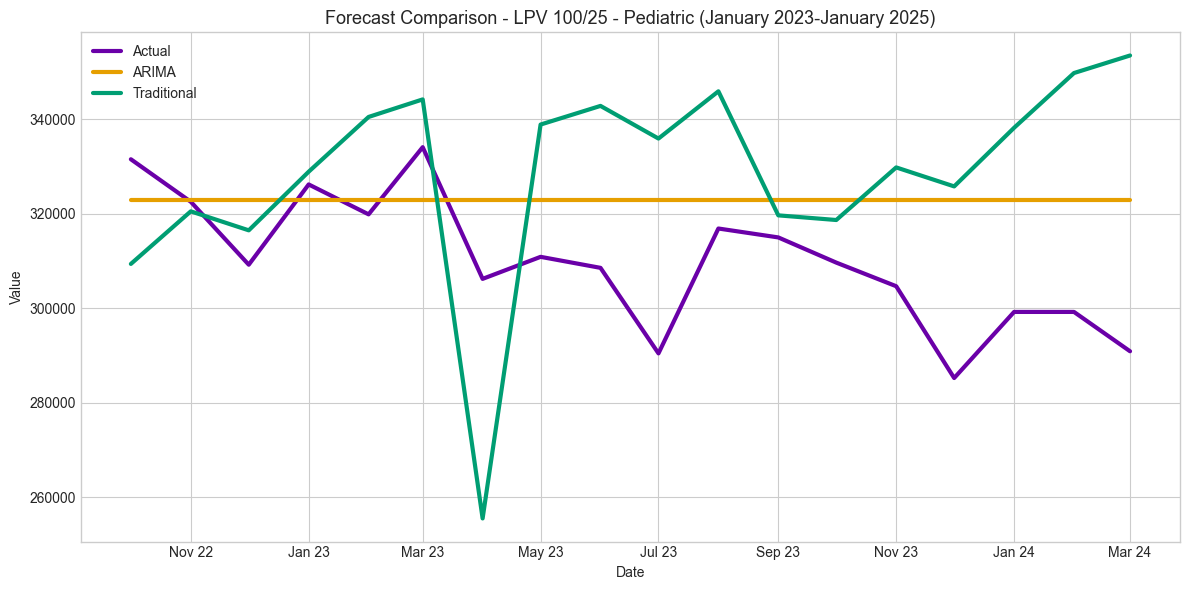

In [1048]:
plt.figure(figsize=(12, 6))

plt.plot(results_df.index, results_df['Actual'], label='Actual', linestyle='-', linewidth=3, color="#6A00A8")
# Dynamically plot the best model
plt.plot(results_df.index, results_df[best_model], label=best_model, linestyle='-', linewidth=3, color="#E69F00")
plt.plot(results_df.index, results_df['Traditional'], label='Traditional', linestyle='-', linewidth=3, color='#009E73')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f'Forecast Comparison - {drug_name} (January 2023-January 2025)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

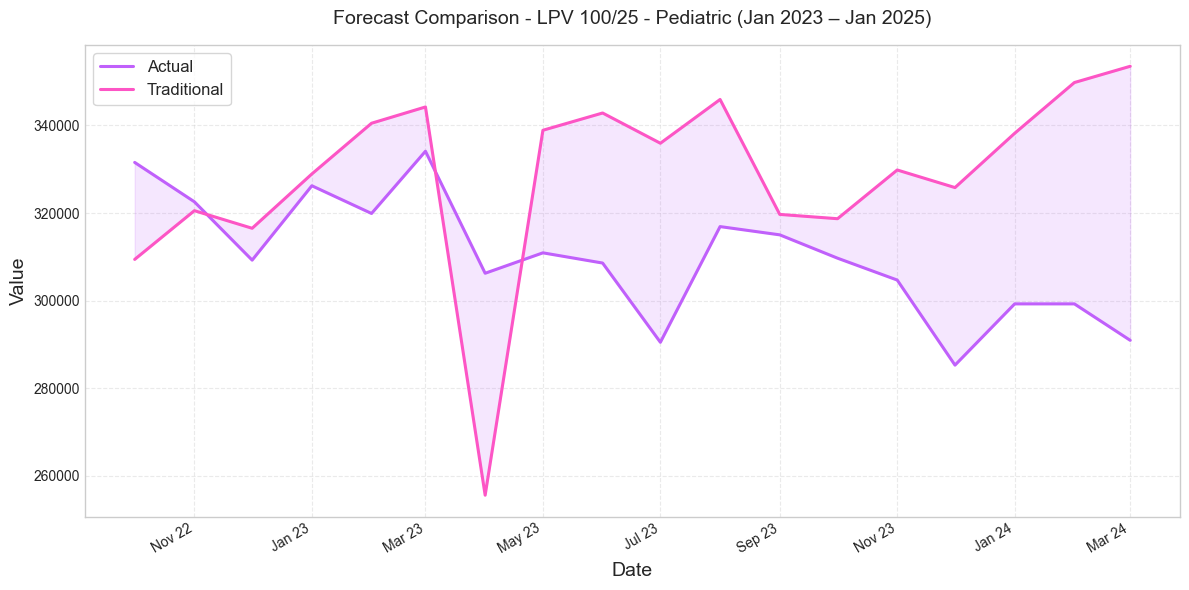

In [1049]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(results_df.index,
                results_df['Actual'],
                results_df['Traditional'],
                color="#C060FB",
                alpha=0.15,
                label="_nolegend_")

ax.plot(results_df.index, results_df['Actual'],
        label='Actual',
        linestyle='-',
        linewidth=2.2,
        color="#C060FB")

ax.plot(results_df.index, results_df['Traditional'],
        label='Traditional',
        linestyle='-',
        linewidth=2.2,
        color="#FD55C5")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=30, ha="right")
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Value", fontsize=14)
ax.set_title(f"Forecast Comparison - {drug_name} (Jan 2023 – Jan 2025)",
             fontsize=14, pad=15)
ax.legend(frameon=True, fontsize=12, loc="upper left", fancybox=True)

plt.tight_layout()
plt.savefig(f"synth_comparison_graphs/{sanitized_drug_name}_actual_vs_traditional.png", dpi=300)
plt.show()

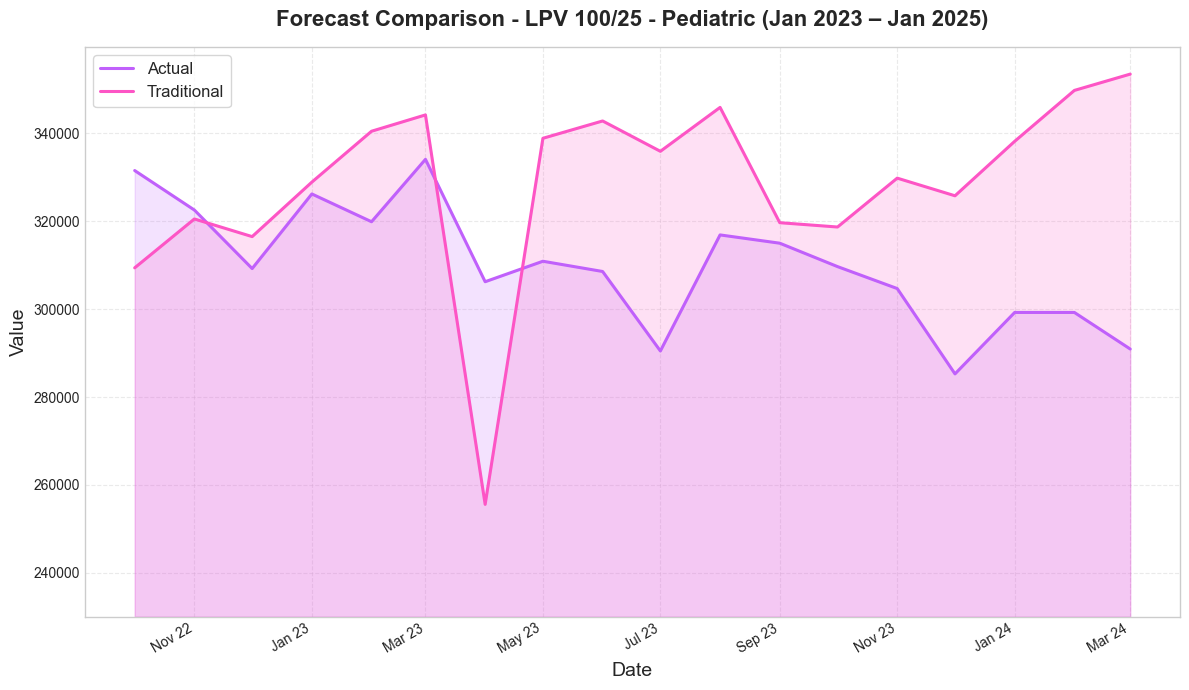

In [1050]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))

baseline = int(results_df[['Actual', 'Traditional']].min().min() * 0.9)

ax.fill_between(results_df.index,
                results_df['Actual'],
                baseline,
                color="#C060FB",
                alpha=0.18,
                zorder=1)

ax.fill_between(results_df.index,
                results_df['Traditional'],
                baseline,
                color="#FD55C5",
                alpha=0.18,
                zorder=1)

ax.plot(results_df.index, results_df['Actual'],
        label='Actual',
        linestyle='-',
        linewidth=2.2,
        color="#C060FB",
        zorder=2)

ax.plot(results_df.index, results_df['Traditional'],
        label='Traditional',
        linestyle='-',
        linewidth=2.2,
        color="#FD55C5",
        zorder=2)

ax.set_ylim(bottom=baseline)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=30, ha="right")
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Value", fontsize=14)
ax.set_title(f"Forecast Comparison - {drug_name} (Jan 2023 – Jan 2025)",
             fontsize=16, pad=15, weight='bold')
ax.legend(frameon=True, fontsize=12, loc="upper left", fancybox=True)

plt.tight_layout()
plt.savefig(f"synth_comparison_graphs/{sanitized_drug_name}_traditional_baseline.png", dpi=300)
plt.show()

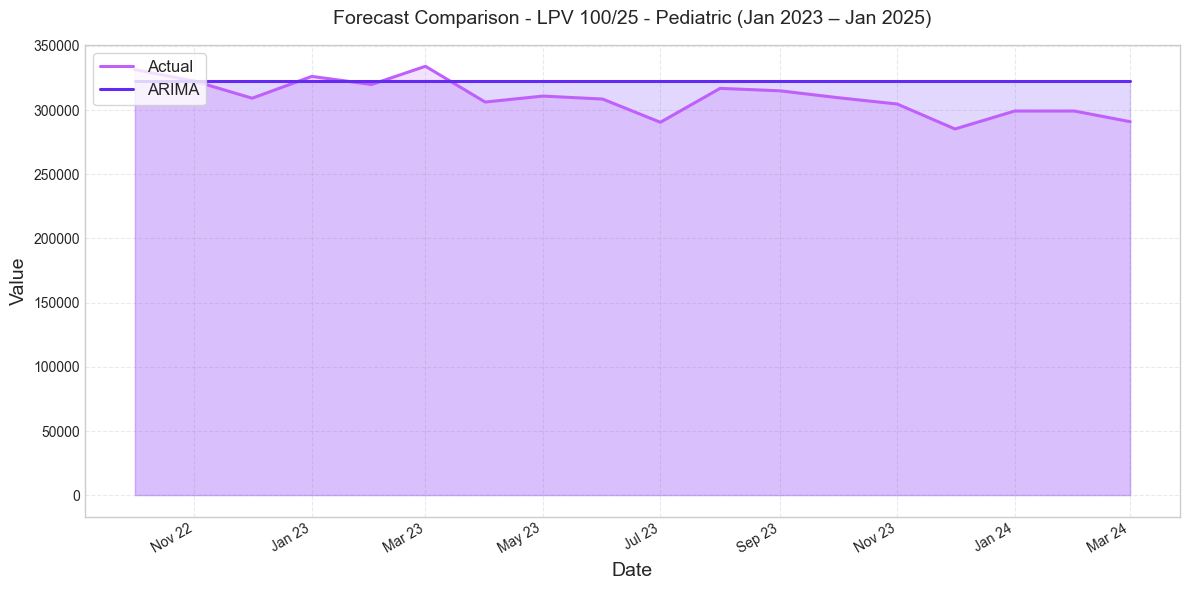

In [1051]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(results_df.index, results_df['Actual'], 0, color="#C060FB", alpha=0.18)
ax.fill_between(results_df.index, results_df[best_model], 0, color="#632AF4", alpha=0.18)
ax.plot(results_df.index, results_df['Actual'], label='Actual', linestyle='-', linewidth=2.2, color="#C060FB")
ax.plot(results_df.index, results_df[best_model], label=best_model, linestyle='-', linewidth=2.2, color="#632AF4")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=30, ha="right")
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Value", fontsize=14)
ax.set_title(f"Forecast Comparison - {drug_name} (Jan 2023 – Jan 2025)", fontsize=14, pad=15)
ax.legend(frameon=True, fontsize=12, loc="upper left", fancybox=True)
plt.tight_layout()
plt.savefig(f"synth_comparison_graphs/{sanitized_drug_name}_actual_vs_best_fill.png", dpi=300)
plt.show()

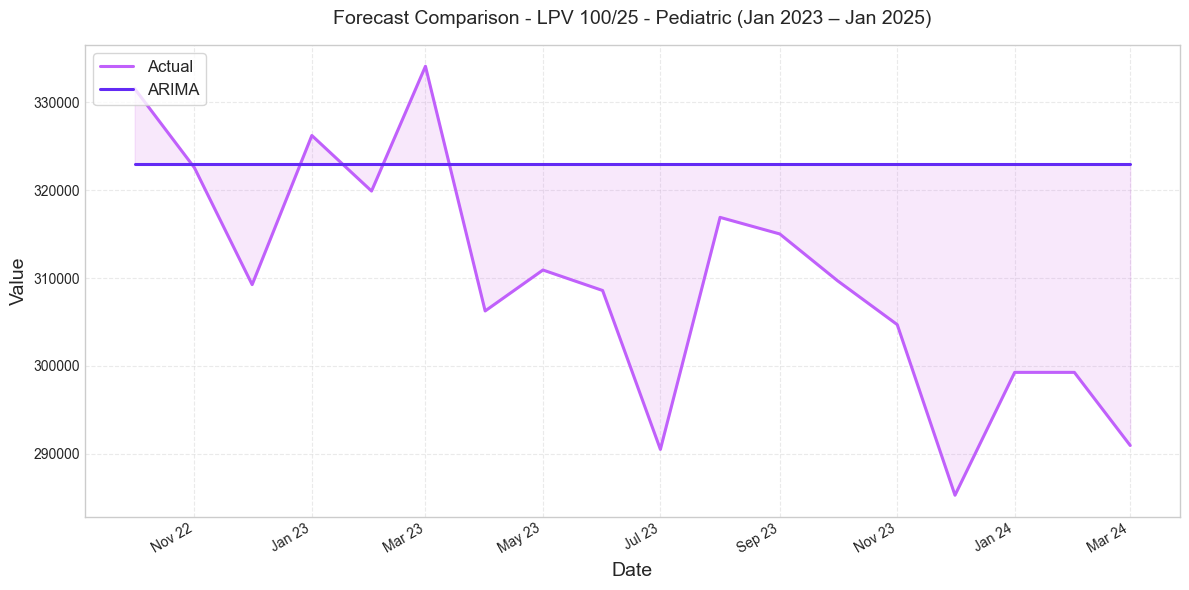

In [1052]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(results_df.index,
                results_df['Actual'],
                results_df[best_model],
                color="#D067EA",
                alpha=0.15,
                label="_nolegend_")

ax.plot(results_df.index, results_df['Actual'],
        label='Actual',
        linestyle='-',
        linewidth=2.2,
        color="#C060FB")

ax.plot(results_df.index, results_df[best_model],
        label=best_model,
        linestyle='-',
        linewidth=2.2,
        color="#632AF4")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.xticks(rotation=30, ha="right")
ax.ticklabel_format(style='plain', axis='y')
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Value", fontsize=14)
ax.set_title(f"Forecast Comparison - {drug_name} (Jan 2023 – Jan 2025)",
             fontsize=14, pad=15)
ax.legend(frameon=True, fontsize=12, loc="upper left", fancybox=True)

plt.tight_layout()
plt.savefig(f"synth_comparison_graphs/{sanitized_drug_name}_actual_vs_best_gap.png", dpi=300)
plt.show()

Storing All Statistical Results for All Drugs

In [1053]:
name_parts = sanitized_drug_name.split(' - ')
base_drug_name = name_parts[0]
drug_type = name_parts[1] if len(name_parts) > 1 else "Unknown"

results_dict = {
    'drug_name': base_drug_name,
    'drug_type': drug_type,
    'spd_traditional': spd_traditional,
    'spd_arima': spd_arima,
    'spd_timesfm': spd_timesfm,
    'spd_timesfm_log': spd_timesfm_log,
    'spd_arimafm_30': spd_arimafm_30,
    'spd_arimafm_70': spd_arimafm_70
}

result_row = pd.DataFrame([results_dict])
csv_path = 'model_results.csv'

if not os.path.exists(csv_path):
    result_row.to_csv(csv_path, index=False)
else:
    existing_df = pd.read_csv(csv_path)
    if sanitized_drug_name not in (existing_df['drug_name'] + ' - ' + existing_df['drug_type']).values:
        result_row.to_csv(csv_path, mode='a', index=False, header=False)

Saving Graph Results

In [1054]:
# saving the table to a CSV file
future_table_output_dir = "synth_tables"
os.makedirs(future_table_output_dir, exist_ok=True)

future_table_file_path = os.path.join(future_table_output_dir, f"{sanitized_drug_name} Future Predictions Table.csv")
results_df.to_csv(future_table_file_path)

print(f"Table saved in {future_table_file_path}")

Table saved in synth_tables/LPV 100_25 - Pediatric Future Predictions Table.csv
